In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Carichiamo i dataset
buurten = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat_2.json")
green = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\park_geojson_lnglat.json", on_invalid="ignore")
fietsen = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\fietsnetten_geojson_lnglat.json")

# Convertiamo tutto in EPSG:28992 — sistema olandese in metri
buurten_proj = buurten.to_crs("EPSG:28992")
green_proj = green.to_crs("EPSG:28992")
fietsen_proj = fietsen.to_crs("EPSG:28992")

print(f"Quartieri: {len(buurten_proj)}")
print(f"Parchi: {len(green_proj)}")
print(f"Piste ciclabili: {len(fietsen_proj)}")
print("CRS: EPSG:28992 (metri)")

Quartieri: 518
Parchi: 125
Piste ciclabili: 8391
CRS: EPSG:28992 (metri)


In [2]:
# Buffer di 500 metri attorno ai parchi
buffer_500 = green_proj.copy()
buffer_500['geometry'] = green_proj.geometry.buffer(500)

# Uniamo tutti i buffer in un unico poligono
buffer_union = buffer_500.union_all()

# Calcoliamo la superficie coperta
area_amsterdam = buurten_proj.union_all().area / 1_000_000  # km²
area_coperta = buffer_union.area / 1_000_000  # km²

print(f"Superficie totale Amsterdam: {area_amsterdam:.1f} km²")
print(f"Superficie entro 500m da un parco: {area_coperta:.1f} km²")
print(f"Percentuale coperta: {area_coperta/area_amsterdam*100:.1f}%")

Superficie totale Amsterdam: 243.6 km²
Superficie entro 500m da un parco: 140.8 km²
Percentuale coperta: 57.8%


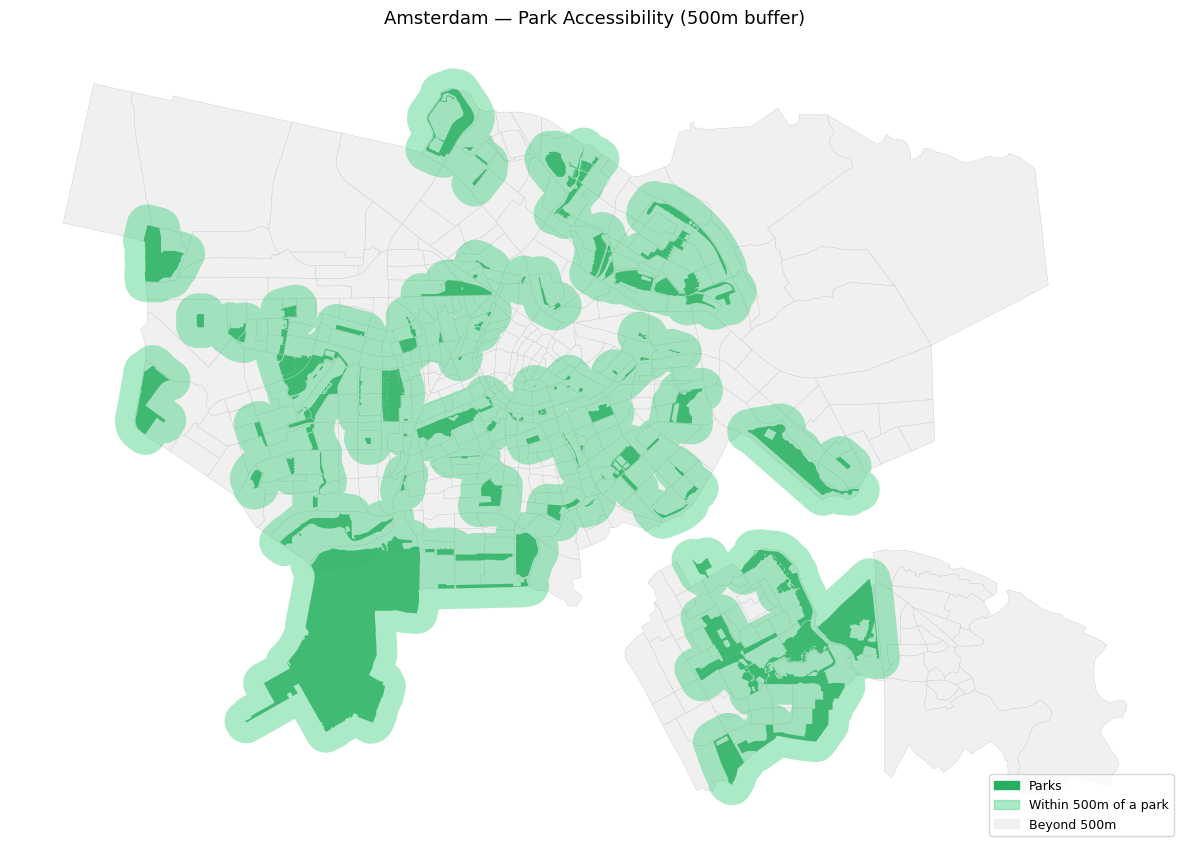

In [3]:
import matplotlib.patches as mpatches
from shapely.geometry import shape

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Sfondo — tutta Amsterdam in grigio chiaro
buurten_proj.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.3)

# Area entro 500m dai parchi in verde
gpd.GeoSeries([buffer_union]).plot(ax=ax, color='#2ecc71', alpha=0.4)

# Parchi in verde scuro
green_proj.plot(ax=ax, color='#27ae60', alpha=0.8)

# Legenda
patch1 = mpatches.Patch(color='#27ae60', label='Parks')
patch2 = mpatches.Patch(color='#2ecc71', alpha=0.4, label='Within 500m of a park')
patch3 = mpatches.Patch(color='#f0f0f0', label='Beyond 500m')
ax.legend(handles=[patch1, patch2, patch3], fontsize=9, loc='lower right')

ax.set_title('Amsterdam — Park Accessibility (500m buffer)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_park_accessibility.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Per ogni quartiere calcoliamo la percentuale di area coperta dal buffer
buurten_proj['area_totale'] = buurten_proj.geometry.area

# Intersezione tra quartieri e buffer
buurten_proj['area_coperta'] = buurten_proj.geometry.intersection(buffer_union).area

# Percentuale di accessibilità
buurten_proj['accessibilita'] = (buurten_proj['area_coperta'] / buurten_proj['area_totale'] * 100).round(1)

# Aggreghiamo per Stadsdeel
access_stadsdeel = buurten_proj.groupby('Stadsdeel')['accessibilita'].mean().round(1).sort_values(ascending=False)
print(access_stadsdeel)

Stadsdeel
Zuid          86.7
West          84.9
Zuidoost      77.2
Noord         75.7
Nieuw-West    74.2
Oost          72.9
Centrum       65.4
Weesp         14.6
Westpoort     13.1
Name: accessibilita, dtype: float64


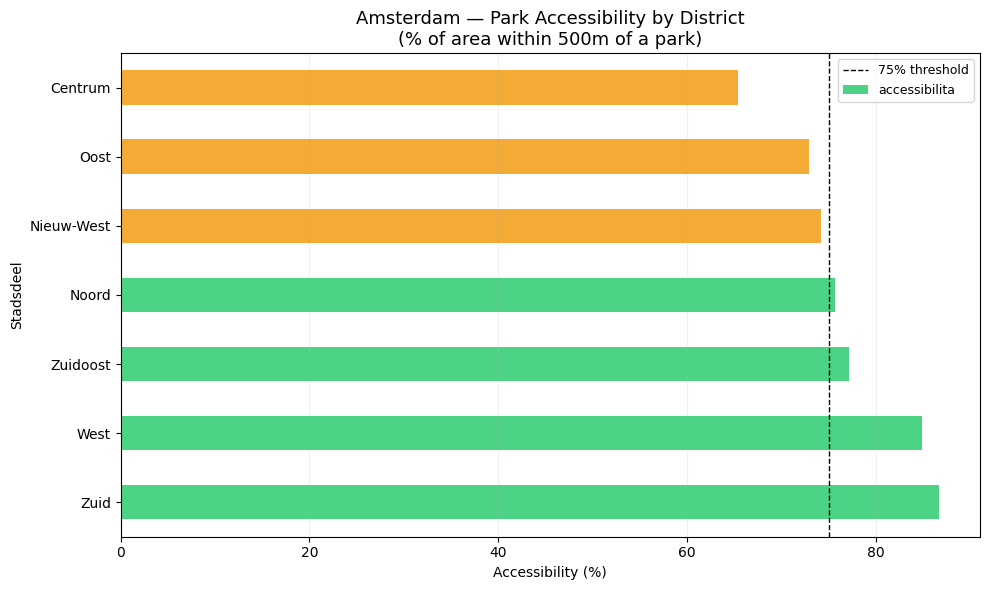

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

# Escludiamo Weesp e Westpoort che sono casi atipici
access_plot = access_stadsdeel[~access_stadsdeel.index.isin(['Weesp', 'Westpoort'])]

colori = ['#2ecc71' if v > 75 else '#f39c12' if v > 60 else '#e74c3c' 
          for v in access_plot.values]

access_plot.plot(kind='barh', ax=ax, color=colori, alpha=0.85)

ax.set_title('Amsterdam — Park Accessibility by District\n(% of area within 500m of a park)', fontsize=13)
ax.set_xlabel('Accessibility (%)')
ax.axvline(x=75, color='black', linestyle='--', linewidth=1, label='75% threshold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.savefig('amsterdam_accessibility_chart.png', dpi=150, bbox_inches='tight')
plt.show()

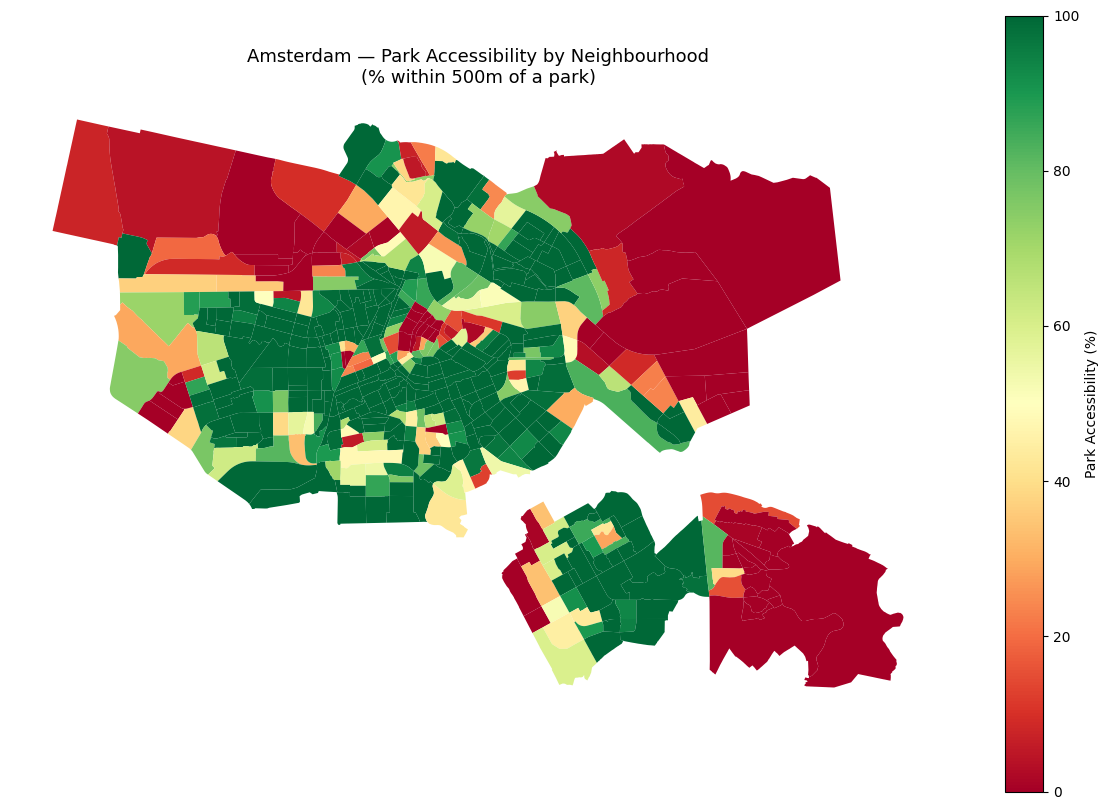

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

buurten_proj.plot(
    column='accessibilita',
    cmap='RdYlGn',
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Park Accessibility (%)', 'shrink': 0.8},
    missing_kwds={'color': 'lightgrey'}
)

ax.set_title('Amsterdam — Park Accessibility by Neighbourhood\n(% within 500m of a park)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_accessibility_map.png', dpi=150, bbox_inches='tight')
plt.show()